<a href="https://colab.research.google.com/github/Olga-Lyt/DTA-2026/blob/main/HW/practice_stat_tests_HARDER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Статистичні тести: поглиблений практикум

**Рівень:** середній+ · фокус на **інтерпретації** · бібліотека `scipy.stats`

---

Цей практикум складніший за попередній. Тут менше «механічного» застосування тестів і більше **роздумів**: ви будете обирати тести самостійно, помічати пастки і — найголовніше — **пояснювати, що результат означає для бізнесу**.

### Що нового порівняно з минулим практикумом
- 🧠 Більшість завдань вимагають, щоб ви **самі обрали тест** і обґрунтували вибір.
- 🪤 Тут є **пастки**: випадки, де p < 0.05, але результат практично не важливий; де дані спотворені викидами; де результат «на межі».
- 💬 На кожне завдання — **розгорнута інтерпретація**. Саме це відрізняє аналітика від калькулятора.

### Як працювати
1. До кожного завдання є **підказки** — користуйтесь ними, але спершу подумайте самі.
2. Інтерпретації пишіть так, ніби пояснюєте керівнику **без** статистичної освіти.
3. Не зупиняйтесь на «p < 0.05, значущо» — завжди питайте: *наскільки великий ефект? чи це важливо на практиці? чи можна довіряти даним?*

> ⚠️ Головна теза практикуму: **статистична значущість ≠ практична важливість.** Тримайте це в голові протягом усієї роботи.

---

## Підготовка

Працюємо з даними SaaS-продукту (онлайн-сервіс за підпискою). Запустіть клітинку нижче.

**`saas_users.csv`** — 1200 користувачів:

| Стовпець | Опис | Тип |
|---|---|---|
| `user_id` | ID користувача | — |
| `plan` | Тариф (Free / Pro / Business) | категоріальний |
| `region` | Регіон (Europe / Americas / Asia) | категоріальний |
| `signup_source` | Джерело реєстрації (Search / Referral / Ads / Social) | категоріальний |
| `support_tickets` | Кількість звернень у підтримку | числовий |
| `weekly_sessions` | Сеансів на тиждень | числовий |
| `feature_adopted` | Чи почав користуватись новою функцією (Так/Ні) | категоріальний |
| `nps_before` | Оцінка лояльності NPS ДО оновлення (0-10) | числовий |
| `nps_after` | NPS ПІСЛЯ оновлення (0-10) | числовий |

**`onboarding_ab.csv`** — A/B-тест нового онбордингу (100 000 користувачів!):

| Стовпець | Опис |
|---|---|
| `user_id` | ID |
| `variant` | Control (старий онбординг) або Treatment (новий) |
| `signed_up` | Чи завершив реєстрацію (1/0) |


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

users = pd.read_csv("saas_users.csv")
ab = pd.read_csv("onboarding_ab.csv")

print("Користувачі:", users.shape)
print("A/B онбординг:", ab.shape)
users.head()

Користувачі: (1200, 9)
A/B онбординг: (100000, 3)


,user_id,plan,region,signup_source,support_tickets,weekly_sessions,feature_adopted,nps_before,nps_after
0,10001,Free,Americas,Social,2,11,Так,5,3
1,10002,Pro,Asia,Search,12,16,Ні,6,3
2,10003,Free,Asia,Social,6,11,Ні,5,5
3,10004,Business,Americas,Referral,4,27,Ні,7,7
4,10005,Pro,Asia,Referral,1,8,Ні,4,6


---
# Розділ 1. Спочатку — подивись на дані уважно

## 🟦 Чому це важливо
Перш ніж застосовувати тести, аналітик завжди вивчає дані. Тести роблять припущення (наприклад, t-тест найкраще працює, коли дані приблизно симетричні). Якщо дані сильно спотворені викидами — середнє може вводити в оману, і висновок тесту теж.

#### ✏️ Завдання 1 (код)

Виведіть описову статистику (`.describe()`) для числових стовпців. Окремо порівняйте **середнє** і **медіану** стовпця `support_tickets`.

> 💡 **Підказка:** Для медіани: `users['support_tickets'].median()`. Зверніть увагу, чи сильно середнє відрізняється від медіани.

In [2]:
# Завдання 1:
print(users.describe())
print(f"\nСереднє support_tickets: {users['support_tickets'].mean():.2f}")
print(f"Медіана support_tickets: {users['support_tickets'].median():.2f}")

            user_id  support_tickets  weekly_sessions   nps_before  \
count   1200.000000      1200.000000      1200.000000  1200.000000   
mean   10600.500000         2.105000        11.500833     6.930000   
std      346.554469         2.606333         6.395109     1.916114   
min    10001.000000         0.000000         1.000000     1.000000   
25%    10300.750000         0.000000         7.000000     6.000000   
50%    10600.500000         1.000000        11.000000     7.000000   
75%    10900.250000         3.000000        16.000000     8.000000   
max    11200.000000        20.000000        38.000000    10.000000   

         nps_after  
count  1200.000000  
mean      7.149167  
std       2.200216  
min       0.000000  
25%       6.000000  
50%       7.000000  
75%       9.000000  
max      10.000000  

Середнє support_tickets: 2.10
Медіана support_tickets: 1.00


#### 💬 Інтерпретація 1

Порівняйте середнє і медіану `support_tickets`. Що це говорить про форму розподілу (чи є викиди — користувачі з дуже великою кількістю звернень)? Чому для такого стовпця варто бути обережним із t-тестом?

> 🧭 **Орієнтир для відповіді:** Якщо середнє помітно більше за медіану — розподіл «витягнутий» вправо (є кілька користувачів з дуже багатьма зверненнями). Подумайте, як викиди впливають на середнє.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Порівнюючи середнє значення (2.10) та медіану (1.00) стовпця support_tickets, ми бачимо, що середнє значення значно вище медіани. Це вказує на те, що розподіл кількості звернень до служби підтримки є скошеним вправо. Такий розподіл свідчить про наявність викидів або користувачів, які мають значно більшу кількість звернень, ніж переважна більшість. Медіана є більш стійкою до таких викидів і краще відображає типову кількість звернень.

Для такого сильно скошеного розподілу варто бути обережним з використанням T-тесту, тому що він передбачає, що дані або є нормально розподіленими, або вибірка достатньо велика. Однак, якщо розподіл сильно скошений, а особливо при наявності викидів, середнє може бути нерепрезентативним, і Т-тест може давати ненадійні результати, підвищуючи ризик помилкових висновків про статистичну значущість.

#### ✏️ Завдання 2 (код)

Побудуйте гістограму `support_tickets`, щоб побачити розподіл на власні очі.

> 💡 **Підказка:** `users['support_tickets'].plot(kind='hist', bins=20)` і потім `plt.show()`.

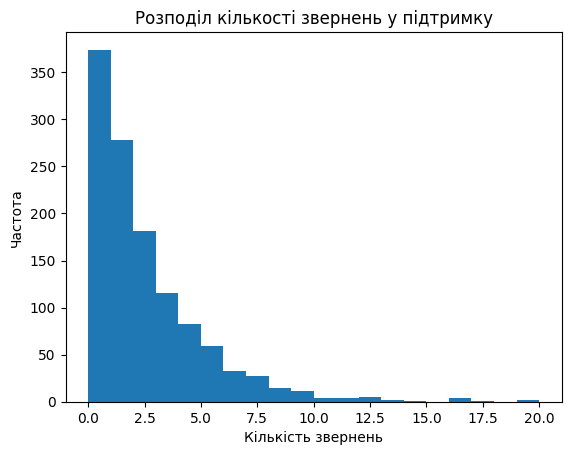

In [3]:
# Завдання 2:
users['support_tickets'].plot(kind='hist', bins=20)
plt.title('Розподіл кількості звернень у підтримку')
plt.xlabel('Кількість звернень')
plt.ylabel('Частота')
plt.show()

#### 💬 Інтерпретація 2

Що видно на гістограмі? Підтверджує вона ваш висновок про викиди з попереднього завдання?

> 🧭 **Орієнтир для відповіді:** Опишіть форму: чи більшість значень малі, а «хвіст» тягнеться до великих? Це типовий скошений (skewed) розподіл.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

На гістограмі видно, що розподіл кількості звернень у підтримку є сильно скошеним вправо. Переважна більшість користувачів має дуже мало звернень, але зрідка трапляються користувачі, які звертаються 10, 15 або навіть 20 разів. Ці поодинокі високі значення утворюють довгий «хвіст» праворуч.

Ця візуалізація повністю підтверджує висновок з попереднього завдання про наявність викидів (користувачів з дуже великою кількістю звернень) і те, що середнє значення не є репрезентативним для більшості даних через вплив цих викидів.

---
# Розділ 2. Порівняння кількох груп — обери тест сам

## 🟦 Нагадування
Коли треба порівняти числову величину між **3+ групами**, згадайте, який тест підходить. Не забувайте: він каже лише, що різниця *десь є*, але не каже, *між якими саме* групами.

#### ✏️ Завдання 3 (код)

Користувачі різних тарифів (`plan`) можуть по-різному користуватись продуктом. Перевірте, чи відрізняється середня кількість сеансів на тиждень (`weekly_sessions`) між тарифами Free / Pro / Business. Спершу виведіть середні по групах, потім проведіть відповідний тест.

> 💡 **Підказка:** Три групи + числова змінна → ANOVA (`stats.f_oneway`). Зберіть групи у список: `[users[users.plan==p].weekly_sessions for p in users.plan.unique()]`.

In [4]:
# Завдання 3:
print(users.groupby('plan')['weekly_sessions'].mean())

free_sessions = users[users['plan'] == 'Free']['weekly_sessions']
pro_sessions = users[users['plan'] == 'Pro']['weekly_sessions']
business_sessions = users[users['plan'] == 'Business']['weekly_sessions']

f_statistic, p_value = stats.f_oneway(free_sessions, pro_sessions, business_sessions)

print(f"\nF-статистика: {f_statistic:.2f}")
print(f"P-значення: {p_value:.3f}")

plan
Business    19.585799
Free         7.931667
Pro         13.299304
Name: weekly_sessions, dtype: float64

F-статистика: 415.19
P-значення: 0.000


#### 💬 Інтерпретація 3

Чи відрізняються тарифи за активністю? Який тариф найактивніший? І ключове питання: чому за результатом ANOVA ви НЕ можете одразу стверджувати, що, наприклад, Pro значущо активніший за Free? Що для цього треба було б зробити додатково?

> 🧭 **Орієнтир для відповіді:** ANOVA виявляє різницю «хоча б десь». Для конкретних пар потрібні post-hoc тести (напр. Тьюкі) або попарні порівняння з поправкою на множинність.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Так, тарифи значущо відрізняються за активністю. Згідно з розрахунками, середні значення weekly_sessions для тарифів складають: Business (19.59), Pro (13.30) та Free (7.93). Найактивнішим тарифом є Business.

F-статистика (415.19) та дуже низьке P-значення (0.000) свідчать про те, що різниця в середній кількості сеансів між тарифними планами є статистично значущою. Це означає, що ми можемо відхилити нульову гіпотезу про відсутність відмінностей між групами.

Однак, за результатом ANOVA ми не можемо одразу стверджувати, що, наприклад, Pro значущо активніший за Free, або Business за Pro. ANOVA лише показує, що хоча б одна пара груп має статистично значущу різницю, але не вказує, які саме пари. Для цього необхідно провести додаткові post-hoc тести (напр. тест Тьюкі), щоб визначити конкретні відмінності між кожною парою тарифів.

#### ✏️ Завдання 4 (код)

Тепер перевірте, чи відрізняється `weekly_sessions` між регіонами (`region`).

> 💡 **Підказка:** Той самий тест, що й вище, але групуєте за `region`.

In [5]:
# Завдання 4:
print(users.groupby('region')['weekly_sessions'].mean())

regions = [users[users.region == r].weekly_sessions for r in users.region.unique()]
f_statistic_region, p_value_region = stats.f_oneway(*regions)

print(f"\nF-статистика (регіони): {f_statistic_region:.2f}")
print(f"P-значення (регіони): {p_value_region:.3f}")

region
Americas    10.783529
Asia        11.523929
Europe      12.283069
Name: weekly_sessions, dtype: float64

F-статистика (регіони): 5.55
P-значення (регіони): 0.004


#### 💬 Інтерпретація 4

Порівняйте цей результат із попереднім (тарифи). В одному випадку різниця значуща, в іншому — ні (або слабша). Що це означає для продукту: який фактор (тариф чи регіон) сильніше пов'язаний з активністю користувача?

> 🧭 **Орієнтир для відповіді:** Зверніть увагу не лише на сам факт значущості, а й на те, наскільки далекі середні між групами одне від одного.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Порівнюючи результати для тарифів та регіонів, можна зробити висновок, що обидва фактори мають статистично значущий вплив на середню кількість сеансів на тиждень, оскільки p-значення в обох випадках нижчі за 0.05 (для тарифів: p < 0.001, для регіонів: p = 0.004).

Однак, тарифний план значно сильніше пов'язаний з активністю користувача, ніж регіон. Це видно з кількох показників:

1.  F-статистика: Для тарифів F-статистика становить 415.19, тоді як для регіонів — лише 5.55. Значно вища F-статистика для тарифів вказує на набагато більшу дисперсію між середніми значеннями груп тарифів порівняно з дисперсією всередині груп.
2.  Розмір різниці середніх: Середні значення weekly_sessions для тарифів варіюються від 7.93 (Free) до 19.59 (Business), що є великим діапазоном. Для регіонів цей діапазон значно менший: від 10.78 (Americas) до 12.28 (Europe).

Отже, для продукту це означає, що тарифний план є набагато більш важливим фактором, що впливає на активність користувачів. Регіон має статистично значущий, але набагато слабший зв'язок з активністю. Це може вказувати на те, що стратегії, спрямовані на різні тарифні плани, матимуть більший вплив на залученість користувачів, ніж стратегії, орієнтовані на регіональні особливості.

---
# Розділ 3. До і після — і розмір ефекту

## 🟦 Новий акцент: розмір ефекту
Тут ви зустрінете важливу пастку. Тест може показати «значущо» (p < 0.05), але **величина зміни** може бути крихітною. Аналітик завжди дивиться на обидві речі: і p-значення, і **наскільки великий** ефект.

#### ✏️ Завдання 5 (код)

Компанія оновила онбординг і виміряла NPS (лояльність) тих самих користувачів до (`nps_before`) і після (`nps_after`). Проведіть відповідний тест. Додатково порахуйте **середню зміну** NPS (різницю after − before).

> 💡 **Підказка:** Ті самі користувачі двічі → парний t-тест (`stats.ttest_rel`). Середня зміна: `(users['nps_after'] - users['nps_before']).mean()`.

In [6]:
# Завдання 5:

t_statistic, p_value = stats.ttest_rel(users['nps_after'], users['nps_before'])
mean_nps_change = (users['nps_after'] - users['nps_before']).mean()

print(f"T-статистика: {t_statistic:.2f}")
print(f"P-значення: {p_value:.3f}")
print(f"Середня зміна NPS (after - before): {mean_nps_change:.2f}")

T-статистика: 5.50
P-значення: 0.000
Середня зміна NPS (after - before): 0.22


#### 💬 Інтерпретація 5

Тут — важлива пастка. Подивіться на p-значення І на розмір зміни. Чи зміна статистично значуща? А наскільки вона велика в балах NPS? Чи варто компанії святкувати «значуще покращення», якщо середній NPS зріс лише на ~0.2 бала з 10? Сформулюйте збалансований висновок.

> 🧭 **Орієнтир для відповіді:** Розрізняйте «статистично значущо» (різниця не випадкова) і «практично важливо» (різниця достатньо велика, щоб мати сенс для бізнесу). Тут перше — так, а друге — під питанням.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Результати показують, що середній NPS дещо зріс. T-статистика 5.50 та P-значення 0.000 свідчать про те, що ця зміна є статистично значущою. Це означає, що підвищення NPS не є випадковістю, і ми можемо бути впевнені, що оновлення онбордингу дійсно призвело до зміни показника лояльності.

Однак, варто звернути увагу на розмір ефекту: середня зміна NPS складає всього 0.22 бали з 10 можливих — це дуже невелика зміна. Навіть якщо вона реальна, вона може не бути достатньо великою, щоб виправдати інвестиції чи зусилля, пов'язані з оновленням. Можливо, варто шукати інші оптимізації, які дадуть більший ефект.



---
# Розділ 4. 🪤 Велика пастка: A/B-тест на 100 000 користувачів

## 🟦 Контекст
Це найважливіший розділ практикуму. Компанія протестувала новий онбординг (Treatment) проти старого (Control) на **100 тисячах** користувачів. Через величезний обсяг даних тут виявляється класична пастка статистики.

#### ✏️ Завдання 6 (код)

Порахуйте конверсію реєстрації (`signed_up`) для кожного варіанта (Control і Treatment). На скільки **відсоткових пунктів** відрізняється конверсія?

> 💡 **Підказка:** `ab.groupby('variant')['signed_up'].mean()`. Відсоткові пункти = різниця часток × 100.

In [7]:
# Завдання 6:

conversion_rates = ab.groupby('variant')['signed_up'].mean()
control_conversion = conversion_rates['Control']
treatment_conversion = conversion_rates['Treatment']

difference_pp = (treatment_conversion - control_conversion) * 100

print(f"Конверсія для Control: {control_conversion:.4f}")
print(f"Конверсія для Treatment: {treatment_conversion:.4f}")
print(f"Різниця конверсій (Treatment - Control) у відсоткових пунктах: {difference_pp:.2f} п.п.")

Конверсія для Control: 0.1988
Конверсія для Treatment: 0.2076
Різниця конверсій (Treatment - Control) у відсоткових пунктах: 0.89 п.п.


💬 Інтерпретація 6  

Яка різниця конверсій між варіантами у відсоткових пунктах? На перший погляд — це багато чи мало?

🧭 Орієнтир для відповіді: Просто опишіть числа поки що. Наприклад, «різниця склала менше 1 відсоткового пункту».

(Відповідайте у клітинці нижче повними реченнями, людською мовою.)

**Ваша відповідь:**

Різниця конверсій між варіантами онбордингу становить 0.89 відсоткового пункту.
Це досить невелика різниця — менше ніж один відсотковий пункт. Хоча новий онбординг (Treatment) показує вищу конверсію, це збільшення виглядає скромним. Однак, для подальших висновків необхідно проводити додаткове дослідження.

#### ✏️ Завдання 7 (код)

Проведіть статистичний тест, щоб перевірити, чи різниця конверсій значуща (дані категоріальні: варіант × signed_up).

> 💡 **Підказка:** Категоріальні дані → хі-квадрат. `pd.crosstab(ab.variant, ab.signed_up)`, потім `stats.chi2_contingency`.

In [8]:
# Завдання 7:
contingency_table = pd.crosstab(ab['variant'], ab['signed_up'])
chi2_statistic, p_value, dof, expected_frequencies = stats.chi2_contingency(contingency_table)

print(f"Таблиця спряженості:\n{contingency_table}")
print(f"\nХі-квадрат статистика: {chi2_statistic:.2f}")
print(f"P-значення: {p_value:.3f}")

Таблиця спряженості:
signed_up      0      1
variant                
Control    40062   9938
Treatment  39618  10382

Хі-квадрат статистика: 12.12
P-значення: 0.000


#### 💬 Інтерпретація 7

🪤 ОСЬ ПАСТКА. Тест майже напевно покаже, що різниця **статистично значуща** (p < 0.05). Але різниця в конверсії — менше 1 відсоткового пункту. Поясніть цей парадокс: як крихітна різниця може бути «значущою»? Яку роль тут відіграє величезний обсяг вибірки (100 тисяч)?

> 🧭 **Орієнтир для відповіді:** При дуже великих вибірках навіть мікроскопічні різниці стають статистично значущими, бо тест дуже «чутливий». Значущість говорить «різниця не нульова», але нічого не каже про те, чи вона ВЕЛИКА.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**



Результати Хі-квадрат тесту показують високу статистичну значущість (P-значення 0.000) для різниці в конверсії між Control та Treatment варіантами. Це означає, що різниця в 0.89 відсоткового пункту не є випадковою та новий онбординг дійсно призвів до зміни конверсії.

Разом з тим, сама різниця в конверсії становить менше 1 відсоткового пункту  (0.89 п.п.). Це дуже маленьке збільшення, але воно виявилось виявилася статистично значущим. Це відбулося через великий обсяг вибірки (100 000 користувачів).
В даному випадку P-значення говорить нам лише про те, що різниця не нульова, але воно нічого не каже про те, наскільки велика або важлива ця різниця. Тому, покладаючись лише на P-значення, можна помилково зробити висновок про важливість незначного ефекту.

#### 💬 Інтерпретація 8

Фінальне рішення аналітика. Уявіть, що впровадження нового онбордингу коштує дорого (треба переписати код, навчити команду). Чи варто впроваджувати Treatment заради приросту в ~0.9 відсоткового пункту? Сформулюйте аргументовану рекомендацію, яка враховує і статистику, і практичний бік.

> 🧭 **Орієнтир для відповіді:** Тут немає єдиної правильної відповіді — важлива логіка. Згадайте: статистична значущість ≠ практична важливість. Варто зважити розмір ефекту проти вартості впровадження та обсягу бізнесу.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Враховуючи, що впровадження нового онбордингу є дорогим процесом (перепис коду, навчання команди), а приріст конверсії становить лише 0.89 відсоткового пункту, я б рекомендувала не впроваджувати Treatment на даному етапі.

Хоча Хі-квадрат тест показав статистичну значущість (p < 0.001), що означає, що різниця не є випадковою, практична важливість цього приросту є мінімальною. Збільшення менш ніж на 1 відсотковий пункт, швидше за все, не виправдає значних витрат ресурсів та часу на його впровадження.



---
# Розділ 5. Зв'язок категорій — і результат «на межі»

## 🟦 Що тренуємо
Тут — звичайний хі-квадрат, але один із результатів буде **близьким до межі 0.05**. Це привід поговорити про те, що поріг 0.05 — умовність, а не магія.

#### ✏️ Завдання 8 (код)

Перевірте, чи пов'язаний тариф (`plan`) із тим, чи почав користувач застосовувати нову функцію (`feature_adopted`). Побудуйте таблицю спряженості і проведіть тест.

> 💡 **Підказка:** Дві категоріальні змінні → хі-квадрат. Не забудьте спершу `pd.crosstab(users.plan, users.feature_adopted)`.

In [9]:
# Завдання 8:
contingency_table_plan_feature = pd.crosstab(users['plan'], users['feature_adopted'])
chi2_statistic_plan_feature, p_value_plan_feature, dof_plan_feature, expected_frequencies_plan_feature = stats.chi2_contingency(contingency_table_plan_feature)

print(f"Таблиця спряженості (Plan vs Feature Adopted):\n{contingency_table_plan_feature}")
print(f"\nХі-квадрат статистика: {chi2_statistic_plan_feature:.2f}")
print(f"P-значення: {p_value_plan_feature:.3f}")

Таблиця спряженості (Plan vs Feature Adopted):
feature_adopted   Ні  Так
plan                     
Business          54  115
Free             453  147
Pro              204  227

Хі-квадрат статистика: 143.13
P-значення: 0.000


#### 💬 Інтерпретація 9

Чи пов'язаний тариф із прийняттям функції? Подивіться на таблицю спряженості: користувачі якого тарифу найчастіше приймають функцію? Що це означає для продуктової стратегії?

> 🧭 **Орієнтир для відповіді:** Порахуйте частку «Так» у кожному тарифі (наприклад, для Business: Так / (Так+Ні)). Порівняйте частки між тарифами.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Так, тариф пов'язаний із прийняттям функції, оскільки p-значення (0.000) значно менше 0.05, що свідчить про статистично значущий зв'язок. Це означає, що розподіл користувачів, які прийняли або не прийняли нову функцію, суттєво відрізняється між тарифними планами.

Проведемо підрахунки для кожного тарифу:
*   Business: 115 / (54 + 115) ≈ 0.68 або 68% користувачів прийняли функцію.
*   Free: 147 / (453 + 147) ≈ 0.245 або 24.5% користувачів прийняли функцію.
*   Pro: 227 / (204 + 227) ≈ 0.527 або 52.7% користувачів прийняли функцію.

Користувачі тарифу Business найчастіше приймають функцію (68%), за ними йдуть користувачі Pro (52.7%), а користувачі Free значно рідше приймають функцію (24.5%).
Цей висновок підтверджує, що Business-користувачі є найбільш зацікавленими в нових функціях. Продуктовій команді варто зосередитися на їхніх потребах і забезпечити легке прийняття функцій для цієї групи, можливо, через цільове навчання або комунікацію.  

Користувачі Pro також демонструють значну готовність до прийняття функцій. Це може бути хороша цільова група для подальших покращень та промоції функцій.  

Низький рівень прийняття функцій серед Free-користувачів може вказувати на те, що функція не є для них актуальною, або ж вони не бачать її цінності. Можливо, варто переглянути, як нові функції представлені Free-користувачам, або навіть розглянути, чи варто взагалі витрачати ресурси на їх залучення до конкретних функцій, якщо вони не є цільовою аудиторією.

#### ✏️ Завдання 9 (код)

Тепер перевірте, чи пов'язане джерело реєстрації (`signup_source`) із прийняттям функції (`feature_adopted`).

> 💡 **Підказка:** Знову хі-квадрат, але для `signup_source` × `feature_adopted`.

In [10]:
# Завдання 9:
contingency_table_source_feature = pd.crosstab(users['signup_source'], users['feature_adopted'])
chi2_statistic_source_feature, p_value_source_feature, dof_source_feature, expected_frequencies_source_feature = stats.chi2_contingency(contingency_table_source_feature)

print(f"Таблиця спряженості (Signup Source vs Feature Adopted):\n{contingency_table_source_feature}")
print(f"\nХі-квадрат статистика: {chi2_statistic_source_feature:.2f}")
print(f"P-значення: {p_value_source_feature:.3f}")

Таблиця спряженості (Signup Source vs Feature Adopted):
feature_adopted   Ні  Так
signup_source            
Ads              208  128
Referral         177  100
Search           227  186
Social            99   75

Хі-квадрат статистика: 7.00
P-значення: 0.072


#### 💬 Інтерпретація 10

Цей результат, імовірно, буде «на межі» (p близько 0.05–0.07). Як трактувати такий пограничний випадок? Чи коректно сказати «майже значущо» і впевнено заявити про зв'язок? Що б ви порадили зробити, перш ніж робити висновок?

> 🧭 **Орієнтир для відповіді:** Поріг 0.05 — умовність. Результат трохи вище 0.05 означає «недостатньо доказів за обраного порогу». Не варто оголошувати зв'язок; розумно зібрати більше даних або поставитись обережно.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

P-значення 0.072 є на межі статистичної значущості, оскільки воно трохи вище традиційного порогу 0.05. У такому випадку, некоректно говорити, що зв'язок є «майже значущим» або впевнено заявляти про його існування.

В даному випадку ми не маємо достатніх статистичних доказів, щоб відкинути нульову гіпотезу на рівні значущості 0.05. Це означає, що ми не можемо впевнено стверджувати, що джерело реєстрації  статистично значущо впливає на прийняття функції. На мою думку, в цьому разі слід бути обережним у висновках і не робити категоричних заяв. Краще рекомендувати подальші дослідження або збір додаткових даних.



---
# Розділ 6. Кореляція та хибні висновки про причинність

## 🟦 Що тренуємо
Числові зв'язки + критичне мислення про причинність.

#### ✏️ Завдання 10 (код)

Перевірте, чи пов'язана кількість звернень у підтримку (`support_tickets`) із кількістю сеансів на тиждень (`weekly_sessions`). Порахуйте кореляцію Пірсона.

> 💡 **Підказка:** `stats.pearsonr(users['support_tickets'], users['weekly_sessions'])`. Дивіться і на r, і на p.

In [11]:
# Завдання 10:
correlation, p_value = stats.pearsonr(users['support_tickets'], users['weekly_sessions'])

print(f"Коефіцієнт кореляції Пірсона: {correlation:.2f}")
print(f"P-значення: {p_value:.3f}")

Коефіцієнт кореляції Пірсона: 0.03
P-значення: 0.316


#### 💬 Інтерпретація 11

Опишіть зв'язок (сила, напрямок, значущість). Уявіть, що колега каже: «Більше звернень у підтримку — значить, треба зменшити кількість сеансів, бо сеанси викликають проблеми». Що не так із цим міркуванням?

> 🧭 **Орієнтир для відповіді:** По-перше, оцініть, чи зв'язок узагалі є (подивіться на r і p). По-друге — навіть за наявності зв'язку кореляція не доводить причинність; напрямок «сеанси → звернення» — лише припущення.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*   Коефіцієнт кореляції Пірсона (r): 0.03. Це дуже низьке значення, що вказує на надзвичайно слабкий позитивний зв'язок, тобто зі збільшенням кількості сеансів трохи збільшується кількість звернень у підтримку, але сила цього зв'язку майже незначна.
*   P-значення: 0.316. Це значення значно вище за традиційний поріг статистичної значущості 0.05. Отже, ми не можемо стверджувати, що існує статистично значущий лінійний зв'язок між support_tickets та weekly_sessions.  
Міркування колеги є хибним, оскільки воно базується на непідтвердженому зв'язку та порушує базовий принцип статистики: кореляція не доводить причинності.
Наш аналіз показує, що статистично значущого зв'язку між цими двома змінними немає (p-значення = 0.316 > 0.05). Коефіцієнт кореляції 0.03 є настільки малим, що навіть якщо б він був статистично значущим, він би не мав практичного сенсу. Це означає, що припущення колеги базується на зв'язку, якого, ймовірно, не існує. Навіть якщо б  ми виявили сильний і статистично значущий зв'язок, це б не означало, що weekly_sessions є причиною support_tickets.

---
# Розділ 7. 🧩 Відкритий кейс: повний аналіз

## 🟦 Завдання-кейс
Тут немає підказок про конкретний тест — ви аналітик, і вам треба самостійно пройти весь шлях. Це імітація реального робочого завдання.

**Ситуація:** керівництво хоче зрозуміти, що відрізняє користувачів тарифу **Business** (найдорожчий) від інших. Ваша мета — знайти хоча б два статистично обґрунтовані інсайти про користувачів Business.

#### ✏️ Завдання 11 (код)

Крок 1. Створіть новий стовпець `is_business`, який дорівнює 'Так', якщо тариф Business, інакше 'Ні'. Це поділить користувачів на дві групи для порівнянь.

> 💡 **Підказка:** `users['is_business'] = (users['plan'] == 'Business').map({True:'Так', False:'Ні'})` або через `np.where`.

In [12]:
# Завдання 11:
users['is_business'] = (users['plan'] == 'Business').map({True:'Так', False:'Ні'})
display(users.head())

,user_id,plan,region,signup_source,support_tickets,weekly_sessions,feature_adopted,nps_before,nps_after,is_business
0,10001,Free,Americas,Social,2,11,Так,5,3,Ні
1,10002,Pro,Asia,Search,12,16,Ні,6,3,Ні
2,10003,Free,Asia,Social,6,11,Ні,5,5,Ні
3,10004,Business,Americas,Referral,4,27,Ні,7,7,Так
4,10005,Pro,Asia,Referral,1,8,Ні,4,6,Ні


#### ✏️ Завдання 12 (код)

Крок 2. Сформулюйте і перевірте ПЕРШУ гіпотезу: чи відрізняються Business-користувачі за `weekly_sessions` від решти? Оберіть і проведіть доречний тест.

> 💡 **Підказка:** Дві групи (Business vs решта) + числова змінна → двовибірковий t-тест (`stats.ttest_ind`).

In [13]:
# Завдання 12:
business_users = users[users['is_business'] == 'Так']['weekly_sessions']
non_business_users = users[users['is_business'] == 'Ні']['weekly_sessions']

print(f"Середня кількість сеансів на тиждень для Business-користувачів: {business_users.mean():.2f}")
print(f"Середня кількість сеансів на тиждень для не-Business користувачів: {non_business_users.mean():.2f}")

t_statistic, p_value = stats.ttest_ind(business_users, non_business_users)

print(f"\nT-статистика: {t_statistic:.2f}")
print(f"P-значення: {p_value:.3f}")

Середня кількість сеансів на тиждень для Business-користувачів: 19.59
Середня кількість сеансів на тиждень для не-Business користувачів: 10.18

T-статистика: 20.63
P-значення: 0.000


#### 💬 Інтерпретація 12

Сформулюйте перший інсайт: чим Business-користувачі відрізняються за активністю? Наведіть і числа (середні), і висновок тесту.

> 🧭 **Орієнтир для відповіді:** Порівняйте середні двох груп і вкажіть, чи різниця значуща. Перекладіть це мовою бізнесу.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**



Середня кількість сеансів на тиждень для Business-користувачів становить 19.59, тоді як для всіх інших користувачів цей показник значно нижчий — 10.18 сеансів на тиждень.

Результати двовибіркового t-тесту (T-статистика: 20.63, P-значення: 0.000) підтверджують, що ця різниця є статистично  значущою. Це означає, що такий розрив в активності не є випадковим і Business-клієнти є значно більш залученими та активними користувачами продукту.

#### ✏️ Завдання 13 (код)

Крок 3. Сформулюйте і перевірте ДРУГУ гіпотезу: чи пов'язаний статус Business із прийняттям функції (`feature_adopted`)? Оберіть доречний тест.

> 💡 **Підказка:** Дві категоріальні змінні (`is_business` × `feature_adopted`) → хі-квадрат.

In [14]:
# Завдання 13:
contingency_table_business_feature = pd.crosstab(users['is_business'], users['feature_adopted'])
chi2_statistic_business_feature, p_value_business_feature, dof_business_feature, expected_frequencies_business_feature = stats.chi2_contingency(contingency_table_business_feature)

print(f"Таблиця спряженості (Is Business vs Feature Adopted):\n{contingency_table_business_feature}")
print(f"\nХі-квадрат статистика: {chi2_statistic_business_feature:.2f}")
print(f"P-значення: {p_value_business_feature:.3f}")

Таблиця спряженості (Is Business vs Feature Adopted):
feature_adopted   Ні  Так
is_business              
Ні               657  374
Так               54  115

Хі-квадрат статистика: 59.40
P-значення: 0.000


#### 💬 Інтерпретація 13

Сформулюйте другий інсайт. Чи частіше Business-користувачі приймають нову функцію?

> 🧭 **Орієнтир для відповіді:** Подивіться на частки «Так» у групах Business та не-Business у таблиці спряженості.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Так, статус Business значно пов'язаний із прийняттям функції. Згідно з результатами Хі-квадрат тесту (Хі-квадрат статистика: 59.40, P-значення: 0.000), ми можемо відкинути нульову гіпотезу про відсутність зв'язку.

Аналіз таблиці спряженості:

*   Business-користувачі: 115 / (115 + 54) = 0,68 або 68% прийняли функцію.
*   Не-Business користувачі: 374 / (374 + 657) = 0,36 або 36%  прийняли функцію.

Таким чином, Business-користувачі значно частіше приймають нову функцію (68%) порівняно з не-Business користувачами (36%). Це вказує на те, що Business-сегмент є більш інноваційним та відкритим до нових можливостей продукту, або ж нова функція є більш релевантною для їхніх потреб.

#### 💬 Інтерпретація 14

Підсумок кейсу. Зберіть ваші знахідки в короткий звіт (3-4 речення) для керівництва: який «портрет» Business-користувача вимальовується з даних? Які з висновків статистично надійні, а де варто бути обережним?

> 🧭 **Орієнтир для відповіді:** Хороший звіт поєднує кілька знахідок, чесно зазначає рівень упевненості й уникає тверджень про причинність там, де є лише кореляція.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Аналіз даних свідчить, що Business-користувачі -  це найбільш активний та залучений сегмент клієнтів. Статистично встановлено, що вони мають значно вищу середню кількість сеансів на тиждень (19.59) порівняно з не-Business користувачами (10.18), а також набагато частіше приймають нові функції (68% проти 36%). Ці висновки, підтверджені статистичними тестами з дуже низькими p-значеннями, свідчать про високу цінність та потенціал цього сегмента для розвитку продукту.

---
# 🎉 Готово!

Ви пройшли поглиблений практикум, де головним було не «порахувати p-значення», а **зрозуміти й пояснити** результат.

## Що ви потренували
- ✅ Самостійний вибір тесту під задачу
- ✅ Розрізнення **статистичної значущості** та **практичної важливості** (пастка з 100 000 користувачів)
- ✅ Увагу до **розміру ефекту**, а не лише до p < 0.05
- ✅ Обережність із **скошеними даними** та викидами
- ✅ Трактування **пограничних** результатів (p ≈ 0.05)
- ✅ Критичне мислення про **причинність** (кореляція ≠ причина)
- ✅ Складання звіту для бізнесу

## Головна думка
> P-значення — це початок розмови, а не її кінець. Хороший аналітик завжди питає далі: *наскільки великий ефект? чи це важливо? чи можна довіряти даним? чи це причина — чи лише зв'язок?*

Якщо ви відчуваєте, що на ці питання вмієте відповідати — ви виросли від «людини, що рахує тести» до **аналітика, що ухвалює рішення**. 📊
